# LlmExpl Context Lab

Voir le contexte transformer les représentations

## Expérience 1 — Un même mot, deux contextes

Nous allons suivre **« avocat »** à travers les couches du modèle :

- ⚖️ « L'avocat plaide devant le tribunal. »
- 🥑 « Elle ajoute de l'avocat dans la salade. »

**Question : à quel moment les deux représentations commencent-elles à se distinguer ?**

### 1. Préparer le laboratoire

Nous utilisons le même modèle multilingue MPNet que dans LlmExpl et observons ses états internes *avant* le pooling.

In [84]:
import numpy as np
import pandas as pd
import plotly.express as px
import torch
from sklearn.decomposition import PCA
from torch.nn.functional import cosine_similarity
from transformers import AutoModel, AutoTokenizer

MODEL_ID = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
TARGET_WORD = "avocat"
sentences = {
    "⚖️ Justice": "L'avocat plaide devant le tribunal.",
    "🥑 Cuisine": "Elle ajoute de l'avocat dans la salade.",
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calcul sur : {device}")

Calcul sur : cpu


### 2. Charger le modèle et examiner la tokenisation

Les positions de caractères permettent de retrouver « avocat », qu'il corresponde à un ou plusieurs tokens.

In [85]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Architecture : {model.config.model_type}")
print(f"Couches : {model.config.num_hidden_layers}")
print(f"Dimensions : {model.config.hidden_size}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Architecture : xlm-roberta
Couches : 12
Dimensions : 768


In [86]:
def prepare(sentence, word):
    encoded = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
    offsets = encoded.pop("offset_mapping")[0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    start = sentence.lower().index(word.lower())
    end = start + len(word)
    indices = [i for i, (a, b) in enumerate(offsets) if b > start and a < end]
    if not indices:
        raise ValueError(f"Le mot {word!r} n'a pas été retrouvé.")
    return encoded, tokens, offsets, indices

prepared, rows = {}, []
for context, sentence in sentences.items():
    encoded, tokens, offsets, indices = prepare(sentence, TARGET_WORD)
    prepared[context] = (encoded, indices)
    for i, (token, offset) in enumerate(zip(tokens, offsets)):
        rows.append({"Contexte": context, "Position": i, "Token": token,
                     "Caractères": str(tuple(offset)),
                     "Mot suivi": "← avocat" if i in indices else ""})

pd.DataFrame(rows)

,Contexte,Position,Token,Caractères,Mot suivi
0,⚖️ Justice,0,<s>,"(0, 0)",
1,⚖️ Justice,1,▁L,"(0, 1)",
2,⚖️ Justice,2,',"(1, 2)",
3,⚖️ Justice,3,avo,"(2, 5)",← avocat
4,⚖️ Justice,4,cat,"(5, 8)",← avocat
5,⚖️ Justice,5,▁pla,"(9, 12)",
6,⚖️ Justice,6,ide,"(12, 15)",
7,⚖️ Justice,7,▁devant,"(16, 22)",
8,⚖️ Justice,8,▁le,"(23, 25)",
9,⚖️ Justice,9,▁tribunal,"(26, 34)",


### 3. Suivre « avocat » à travers les couches

L'état 0 précède les couches Transformer. Les états 1 à 12 sont leurs sorties. Si le mot occupe plusieurs tokens, leurs vecteurs sont moyennés.

In [87]:
trajectories = {}
with torch.inference_mode():
    for context, (encoded, indices) in prepared.items():
        inputs = {name: value.to(device) for name, value in encoded.items()}
        output = model(**inputs, output_hidden_states=True, return_dict=True)
        trajectories[context] = torch.stack([
            state[0, indices, :].mean(dim=0).cpu()
            for state in output.hidden_states
        ])

print(f"{len(next(iter(trajectories.values())))} états observés.")

13 états observés.


### 4. Mesurer la séparation

Une similarité cosinus proche de 1 indique deux directions proches. Sa diminution révèle l'effet différenciateur du contexte.

In [88]:
justice = trajectories["⚖️ Justice"]
cuisine = trajectories["🥑 Cuisine"]
similarities = cosine_similarity(justice, cuisine, dim=1).numpy()

metrics = pd.DataFrame({
    "État": np.arange(len(similarities)),
    "Étape": ["Représentation initiale"] + [f"Couche {i}" for i in range(1, len(similarities))],
    "Similarité cosinus": similarities,
    "Distance euclidienne": torch.linalg.vector_norm(justice - cuisine, dim=1).numpy(),
})
display(metrics.round(4))

fig = px.line(metrics, x="État", y="Similarité cosinus", markers=True,
              hover_name="Étape",
              title="Quand les deux « avocat » commencent-ils à diverger ?")
fig.update_traces(line=dict(width=3), marker=dict(size=9, color="#7c3aed"))
fig.update_layout(template="plotly_white", yaxis_range=[-0.05, 1.05],
                  hovermode="x unified")
fig.show()

,État,Étape,Similarité cosinus,Distance euclidienne
0,0,Représentation initiale,0.9609,2.5200
1,1,Couche 1,0.9175,6.0017
2,2,Couche 2,0.9104,6.9881
3,3,Couche 3,0.9140,7.7907
4,4,Couche 4,0.9127,8.5508
5,5,Couche 5,0.9067,9.8077
6,6,Couche 6,0.8822,10.7177
7,7,Couche 7,0.8950,10.8714
8,8,Couche 8,0.8988,11.0754
9,9,Couche 9,0.9338,8.8492


### 5. Voir les trajectoires

La PCA projette les 26 représentations dans un même plan. C'est un trou de serrure utile, pas une image complète des 768 dimensions.

In [89]:
contexts = list(trajectories)
vectors = np.vstack([trajectories[c].numpy() for c in contexts])
pca = PCA(n_components=2)
xy = pca.fit_transform(vectors)

rows, cursor = [], 0
for context in contexts:
    for state in range(len(trajectories[context])):
        rows.append({"Contexte": context, "État": state,
                     "Étape": "Représentation initiale" if state == 0 else f"Couche {state}",
                     "PCA 1": xy[cursor, 0], "PCA 2": xy[cursor, 1]})
        cursor += 1
trajectory_df = pd.DataFrame(rows)

fig = px.line(trajectory_df, x="PCA 1", y="PCA 2", color="Contexte",
              markers=True, text="État", hover_name="Étape",
              color_discrete_map={"⚖️ Justice": "#2563eb", "🥑 Cuisine": "#16a34a"},
              title="Trajectoire d'« avocat » à travers les couches")
fig.update_traces(line=dict(width=3), marker=dict(size=9), textposition="top center")
variance = 100 * pca.explained_variance_ratio_.sum()
fig.update_layout(template="plotly_white",
                  title=f"Trajectoire d'« avocat » à travers les couches<br><sup>Projection : {variance:.1f} % de variance conservée</sup>")
fig.show()

### 6. Lire l'expérience

Après exécution, observons :

1. la tokenisation d'« avocat » ;
2. les couches où la similarité diminue le plus ;
3. la forme des trajectoires dans la projection ;
4. ce que cette image permet — ou non — d'affirmer.

> **Prudence :** une séparation montre un effet du contexte. Elle ne prouve pas à elle seule que le modèle possède deux concepts humains parfaitement distincts.

## Expérience 2 — Deux sens de `mouse`, deux instruments

Nous comparons maintenant le même mot cible dans deux contextes fortement polysémiques :

- 🐭 `The mouse ate the cheese.`
- 🖱️ `I clicked the icon with the mouse.`

La vue 3D montre la géométrie projetée ; la courbe mesure directement la proximité dans l'espace complet.

In [90]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

mouse_sentences = {
    "🐭 Animal": "The mouse ate the cheese.",
    "🖱️ Computer": "I clicked the icon with the mouse.",
}

mouse_trajectories = {}
with torch.inference_mode():
    for context, sentence in mouse_sentences.items():
        encoded, _, _, indices = prepare(sentence, "mouse")
        inputs = {name: value.to(device) for name, value in encoded.items()}
        output = model(**inputs, output_hidden_states=True, return_dict=True)
        mouse_trajectories[context] = torch.stack([
            state[0, indices, :].mean(dim=0).cpu()
            for state in output.hidden_states
        ])

contexts = list(mouse_trajectories)
vectors = np.vstack([mouse_trajectories[c].numpy() for c in contexts])
pca3 = PCA(n_components=3)
xyz = pca3.fit_transform(vectors)

n_states = len(mouse_trajectories[contexts[0]])
layers = np.arange(n_states)
labels = np.array(["Représentation initiale"] + [f"Couche {i}" for i in layers[1:]])
similarities = cosine_similarity(
    mouse_trajectories[contexts[0]], mouse_trajectories[contexts[1]], dim=1
).numpy()

fig = make_subplots(
    rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "xy"}]],
    column_widths=[0.62, 0.38], horizontal_spacing=0.05,
    subplot_titles=("Trajectoires PCA 3D", "Similarité cosinus"),
)
colors = {"🐭 Animal": "#2563eb", "🖱️ Computer": "#f97316"}

cursor = 0
for context in contexts:
    points = xyz[cursor:cursor + n_states]
    fig.add_trace(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode="lines+markers", name=context, customdata=labels,
        line=dict(color=colors[context], width=6),
        marker=dict(color=colors[context], size=5),
        hovertemplate=("<b>%{customdata}</b><br>" + context +
                       "<br>PC1=%{x:.2f}<br>PC2=%{y:.2f}<br>PC3=%{z:.2f}<extra></extra>"),
    ), row=1, col=1)
    cursor += n_states

fig.add_trace(go.Scatter(
    x=layers, y=similarities, mode="lines+markers", name="Similarité",
    customdata=labels, line=dict(color="#7c3aed", width=3),
    marker=dict(size=8),
    hovertemplate="<b>%{customdata}</b><br>Similarité=%{y:.4f}<extra></extra>",
), row=1, col=2)

variance = 100 * pca3.explained_variance_ratio_
fig.update_scenes(
    xaxis_title=f"PC1 ({variance[0]:.1f} %)",
    yaxis_title=f"PC2 ({variance[1]:.1f} %)",
    zaxis_title=f"PC3 ({variance[2]:.1f} %)",
)
fig.update_xaxes(title_text="État / couche", dtick=1, row=1, col=2)
fig.update_yaxes(title_text="Similarité cosinus", range=[-0.05, 1.05], row=1, col=2)
fig.update_layout(
    template="plotly_white", height=650, width=1200,
    title="Un même token, deux contextes : ce que l'on voit et ce que l'on mesure",
    legend=dict(orientation="h", y=1.08, x=0),
)
fig.show()

## Expérience 3 — Isoler le déplacement produit par le contexte

La représentation brute contient une forte composante commune liée au token `mouse`. Nous la retirons, couche par couche, en prenant `mouse` isolé comme point de référence :

$$\Delta_l^{contexte} = h_l^{contexte} - h_l^{mouse\ isolé}$$

Nous observons ainsi non plus la position du mot, mais la **direction dans laquelle chaque contexte le déplace**. La norme du delta indique l'ampleur du déplacement ; le cosinus compare leurs directions.

In [91]:
# Trajectoire de référence : le token `mouse` sans contexte lexical.
encoded, _, _, indices = prepare("mouse", "mouse")
with torch.inference_mode():
    inputs = {name: value.to(device) for name, value in encoded.items()}
    output = model(**inputs, output_hidden_states=True, return_dict=True)
    isolated_mouse = torch.stack([
        state[0, indices, :].mean(dim=0).cpu()
        for state in output.hidden_states
    ])

deltas = {context: trajectory - isolated_mouse
          for context, trajectory in mouse_trajectories.items()}
delta_vectors = np.vstack([deltas[c].numpy() for c in contexts])
delta_pca = PCA(n_components=2).fit(delta_vectors)
projected_origin = delta_pca.transform(np.zeros((1, delta_vectors.shape[1])))[0]
delta_xy = {c: delta_pca.transform(deltas[c].numpy()) - projected_origin
            for c in contexts}
norms = {c: torch.linalg.vector_norm(deltas[c], dim=1).numpy() for c in contexts}
separation = torch.linalg.vector_norm(deltas[contexts[0]] - deltas[contexts[1]], dim=1).numpy()
similarity = cosine_similarity(deltas[contexts[0]], deltas[contexts[1]], dim=1).numpy()
angles = np.degrees(np.arccos(np.clip(similarity, -1, 1)))

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy", "secondary_y": True}]],
    column_widths=[0.56, 0.44], horizontal_spacing=0.10,
    subplot_titles=("Deux flèches depuis le même point",
                    "Angle, longueurs et séparation"),
)

def arrow_trace(context, layer):
    x, y = delta_xy[context][layer]
    return go.Scatter(
        x=[0, x], y=[0, y], mode="lines+markers", name=context,
        line=dict(color=colors[context], width=5),
        marker=dict(color=colors[context], size=[6, 12]),
        customdata=[[labels[layer], norms[context][layer]]] * 2,
        hovertemplate=("<b>%{customdata[0]}</b><br>" + context +
                       "<br>Longueur=%{customdata[1]:.2f}<extra></extra>"),
    )

def connector_trace(layer):
    a, b = (delta_xy[c][layer] for c in contexts)
    return go.Scatter(
        x=[a[0], b[0]], y=[a[1], b[1]], mode="lines",
        line=dict(color="#64748b", width=2, dash="dot"),
        name="Séparation", showlegend=False, hoverinfo="skip",
    )

for context in contexts:
    fig.add_trace(arrow_trace(context, 0), row=1, col=1)
fig.add_trace(connector_trace(0), row=1, col=1)

fig.add_trace(go.Scatter(
    x=layers, y=angles, mode="lines+markers", name="Angle",
    line=dict(color="#7c3aed", width=3),
    hovertemplate="Couche %{x}<br>Angle=%{y:.1f}°<extra></extra>",
), row=1, col=2, secondary_y=False)
for context in contexts:
    fig.add_trace(go.Scatter(
        x=layers, y=norms[context], mode="lines",
        name=f"Longueur — {context}", line=dict(color=colors[context], width=2),
        hovertemplate="Couche %{x}<br>Longueur=%{y:.2f}<extra></extra>",
    ), row=1, col=2, secondary_y=True)
fig.add_trace(go.Scatter(
    x=layers, y=separation, mode="lines", name="Distance entre les pointes",
    line=dict(color="#475569", width=2, dash="dot"),
    hovertemplate="Couche %{x}<br>Distance=%{y:.2f}<extra></extra>",
), row=1, col=2, secondary_y=True)

fig.frames = [go.Frame(
    name=str(layer),
    data=[arrow_trace(contexts[0], layer),
          arrow_trace(contexts[1], layer),
          connector_trace(layer)],
    traces=[0, 1, 2],
) for layer in layers]
fig.update_layout(sliders=[dict(
    active=0, currentvalue={"prefix": "Couche observée : "},
    steps=[dict(label=str(layer), method="animate",
                args=[[str(layer)], {"mode": "immediate",
                                     "frame": {"duration": 0, "redraw": True},
                                     "transition": {"duration": 0}}])
           for layer in layers],
)])

limit = 1.15 * max(abs(np.vstack(list(delta_xy.values()))).max(), 1e-6)
variance = 100 * delta_pca.explained_variance_ratio_
fig.update_xaxes(title_text=f"PC1 ({variance[0]:.1f} %)",
                 range=[-limit, limit], zeroline=True, row=1, col=1)
fig.update_yaxes(title_text=f"PC2 ({variance[1]:.1f} %)",
                 range=[-limit, limit], scaleanchor="x", scaleratio=1, row=1, col=1)
fig.update_xaxes(title_text="État / couche", dtick=1, row=1, col=2)
fig.update_yaxes(title_text="Angle (degrés)", range=[0, 180],
                 row=1, col=2, secondary_y=False)
fig.update_yaxes(title_text="Longueur / distance",
                 row=1, col=2, secondary_y=True)
fig.update_layout(
    template="plotly_white", height=650, width=1200,
    title="Comment chaque contexte déplace-t-il `mouse` ?",
    legend=dict(orientation="h", y=1.08, x=0),
)
fig.show()

## Expérience 4 — Une sonde sémantique contextualisée pour `mouse`

Comme pour `avocat`, nous construisons deux prototypes à partir de phrases contenant toutes le même token `mouse` :

- 🐭 plusieurs emplois désignant l'animal ;
- 🖱️ plusieurs emplois désignant le périphérique informatique.

Le score affiché est **affinité animale − affinité informatique** : positif vers l'animal, négatif vers l'informatique. Il s'agit d'une sonde descriptive, pas d'une preuve que cet axe correspond exactement à un concept interne du modèle.

In [92]:
mouse_prototypes = {
    "🐭 Animal": [
        "A small mouse ran through the house.",
        "The cat chased the mouse.",
        "The mouse hid under the table.",
    ],
    "🖱️ Informatique": [
        "She moved the pointer with the mouse.",
        "This wireless mouse connects to the computer.",
        "He used the mouse to select the file.",
    ],
}

def mouse_contextual_trajectory(sentence):
    encoded, _, _, indices = prepare(sentence, "mouse")
    with torch.inference_mode():
        inputs = {name: value.to(device) for name, value in encoded.items()}
        output = model(**inputs, output_hidden_states=True, return_dict=True)
    return torch.stack([
        state[0, indices, :].mean(dim=0).cpu()
        for state in output.hidden_states
    ])

mouse_prototype_states = {
    family: torch.stack([mouse_contextual_trajectory(sentence)
                         for sentence in examples]).mean(dim=0)
    for family, examples in mouse_prototypes.items()
}
mouse_scores = {
    context: {
        family: cosine_similarity(trajectory, prototype, dim=1).numpy()
        for family, prototype in mouse_prototype_states.items()
    }
    for context, trajectory in mouse_trajectories.items()
}

animal, computer = mouse_prototypes
mouse_preferences = {context: scores[animal] - scores[computer]
                     for context, scores in mouse_scores.items()}
fig = make_subplots(rows=1, cols=2, subplot_titles=list(mouse_sentences.values()))
for col, context in enumerate(contexts, start=1):
    hover = [[labels[i], mouse_scores[context][animal][i],
              mouse_scores[context][computer][i]] for i in layers]
    fig.add_trace(go.Scatter(
        x=layers, y=mouse_preferences[context], mode="lines+markers",
        name=context, showlegend=False, line=dict(color=colors[context], width=3),
        marker=dict(size=8), customdata=hover,
        hovertemplate=("<b>%{customdata[0]}</b><br>" +
                       "Animal=%{customdata[1]:.4f}<br>" +
                       "Informatique=%{customdata[2]:.4f}<br>" +
                       "Préférence=%{y:+.4f}<extra></extra>"),
    ), row=1, col=col)
    fig.add_trace(go.Scatter(
        x=[layers.min(), layers.max()], y=[0, 0], mode="lines",
        line=dict(color="#94a3b8", dash="dot"),
        showlegend=False, hoverinfo="skip",
    ), row=1, col=col)

fig.update_xaxes(title_text="État / couche", dtick=1)
fig.update_yaxes(title_text="Préférence : animal − informatique", col=1)
fig.update_yaxes(matches="y", col=2)
fig.update_layout(
    template="plotly_white", height=520, width=1200, hovermode="x unified",
    title="À quel prototype contextualisé ressemble chaque `mouse` ?",
)
fig.show()

## Expérience 5 — La même sonde pour `avocat`

Cette fois, les ancres ne sont plus des mots isolés : ce sont des phrases contenant toutes le même token `avocat`. Nous construisons ainsi deux prototypes contextualisés :

- ⚖️ plusieurs emplois juridiques d'`avocat` ;
- 🥑 plusieurs emplois alimentaires d'`avocat`.

Le score affiché est **affinité juridique − affinité alimentaire**. Une valeur positive favorise le prototype juridique ; une valeur négative favorise le prototype alimentaire.

In [93]:
avocat_prototypes = {
    "⚖️ Juridique": [
        "L'avocat défend son client.",
        "Cet avocat prépare le procès.",
        "L'avocat conseille la défense.",
    ],
    "🥑 Alimentaire": [
        "Cet avocat est bien mûr.",
        "Je prépare un guacamole avec l'avocat.",
        "Elle coupe l'avocat pour le déjeuner.",
    ],
}

def contextual_trajectory(sentence, word="avocat"):
    encoded, _, _, indices = prepare(sentence, word)
    with torch.inference_mode():
        inputs = {name: value.to(device) for name, value in encoded.items()}
        output = model(**inputs, output_hidden_states=True, return_dict=True)
    return torch.stack([
        state[0, indices, :].mean(dim=0).cpu()
        for state in output.hidden_states
    ])

prototype_states = {
    family: torch.stack([contextual_trajectory(sentence) for sentence in examples]).mean(dim=0)
    for family, examples in avocat_prototypes.items()
}
avocat_scores = {
    context: {
        family: cosine_similarity(trajectory, prototype, dim=1).numpy()
        for family, prototype in prototype_states.items()
    }
    for context, trajectory in trajectories.items()
}

avocat_contexts = list(trajectories)
avocat_layers = np.arange(len(trajectories[avocat_contexts[0]]))
avocat_labels = np.array(["Représentation initiale"] +
                         [f"Couche {i}" for i in avocat_layers[1:]])
legal, food = avocat_prototypes
preferences = {context: scores[legal] - scores[food]
               for context, scores in avocat_scores.items()}
context_colors = {"⚖️ Justice": "#2563eb", "🥑 Cuisine": "#16a34a"}

fig = make_subplots(rows=1, cols=2, subplot_titles=list(sentences.values()))
for col, context in enumerate(avocat_contexts, start=1):
    hover = [[avocat_labels[i], avocat_scores[context][legal][i],
              avocat_scores[context][food][i]] for i in avocat_layers]
    fig.add_trace(go.Scatter(
        x=avocat_layers, y=preferences[context], mode="lines+markers",
        name=context, showlegend=False, line=dict(color=context_colors[context], width=3),
        marker=dict(size=8), customdata=hover,
        hovertemplate=("<b>%{customdata[0]}</b><br>" +
                       "Juridique=%{customdata[1]:.4f}<br>" +
                       "Alimentaire=%{customdata[2]:.4f}<br>" +
                       "Préférence=%{y:+.4f}<extra></extra>"),
    ), row=1, col=col)
    fig.add_trace(go.Scatter(
        x=[avocat_layers.min(), avocat_layers.max()], y=[0, 0], mode="lines",
        line=dict(color="#94a3b8", dash="dot"),
        showlegend=False, hoverinfo="skip",
    ), row=1, col=col)

fig.update_xaxes(title_text="État / couche", dtick=1)
fig.update_yaxes(title_text="Préférence : juridique − alimentaire", col=1)
fig.update_yaxes(matches="y", col=2)
fig.update_layout(
    template="plotly_white", height=520, width=1200, hovermode="x unified",
    title="À quel prototype contextualisé ressemble chaque `avocat` ?",
)
fig.show()

## Expérience 6 — Ce que chaque couche change

Les courbes précédentes donnent une préférence cumulée. Nous calculons maintenant la contribution apparente de chaque couche :

$$\Delta P_l = P_l - P_{l-1}$$

Une barre positive ou négative indique dans quelle direction notre sonde s'est déplacée pendant cette couche. Elle mesure une **variation détectée par la sonde**, pas une décision consciente ni l'action isolée d'un mécanisme unique.

In [94]:
contribution_panels = [
    (mouse_sentences[contexts[0]], mouse_preferences[contexts[0]], 1, 1,
     "#2563eb", "#f97316", "+ animal / − informatique"),
    (mouse_sentences[contexts[1]], mouse_preferences[contexts[1]], 1, 2,
     "#2563eb", "#f97316", "+ animal / − informatique"),
    (sentences[avocat_contexts[0]], preferences[avocat_contexts[0]], 2, 1,
     "#2563eb", "#16a34a", "+ juridique / − alimentaire"),
    (sentences[avocat_contexts[1]], preferences[avocat_contexts[1]], 2, 2,
     "#2563eb", "#16a34a", "+ juridique / − alimentaire"),
]

fig = make_subplots(
    rows=2, cols=2, vertical_spacing=0.18, horizontal_spacing=0.10,
    subplot_titles=[panel[0] for panel in contribution_panels],
)
for title, preference, row, col, positive_color, negative_color, direction in contribution_panels:
    changes = np.diff(preference)
    layer_numbers = np.arange(1, len(preference))
    bar_colors = np.where(changes >= 0, positive_color, negative_color)
    hover = [[preference[layer], direction] for layer in layer_numbers]
    fig.add_trace(go.Bar(
        x=layer_numbers, y=changes, marker_color=bar_colors, showlegend=False,
        customdata=hover,
        hovertemplate=("<b>Couche %{x}</b><br>Contribution=%{y:+.4f}<br>" +
                       "Préférence cumulée=%{customdata[0]:+.4f}<br>" +
                       "%{customdata[1]}<extra></extra>"),
    ), row=row, col=col)

fig.update_xaxes(title_text="Couche", dtick=1)
fig.update_yaxes(title_text="Variation de préférence", zeroline=True,
                 zerolinewidth=2, zerolinecolor="#475569")
fig.update_layout(
    template="plotly_white", height=820, width=1200,
    title="Quelles couches renforcent ou réduisent la préférence sémantique ?",
    bargap=0.18,
)
fig.show()

## Expériences 7 et 8 — Deux nouvelles polysémies françaises

Nous appliquons la même sonde contextualisée à deux nouveaux mots :

- `vol` : déplacement d'un oiseau ↔ délit ;
- `voile` : voile d'un bateau ↔ tissu porté par une personne.

Pour chaque sens, le prototype est la moyenne de trois représentations du **même token** dans trois phrases d'ancrage. Le score positif correspond au premier sens annoncé dans le titre, le score négatif au second.

In [95]:
def contextual_probe(word, test_sentences, prototypes, positive_label, negative_label, colors):
    # Un prototype par sens, construit au même niveau dans les 12 couches.
    prototype_states = {
        sense: torch.stack([contextual_trajectory(sentence, word)
                            for sentence in examples]).mean(dim=0)
        for sense, examples in prototypes.items()
    }
    test_states = {context: contextual_trajectory(sentence, word)
                   for context, sentence in test_sentences.items()}
    scores = {
        context: {sense: cosine_similarity(states, prototype, dim=1).numpy()
                  for sense, prototype in prototype_states.items()}
        for context, states in test_states.items()
    }
    preference = {context: values[positive_label] - values[negative_label]
                  for context, values in scores.items()}

    local_layers = np.arange(len(next(iter(test_states.values()))))
    local_labels = np.array(["Représentation initiale"] +
                            [f"Couche {i}" for i in local_layers[1:]])
    fig = make_subplots(rows=1, cols=2, subplot_titles=list(test_sentences.values()))
    for col, context in enumerate(test_sentences, start=1):
        hover = [[local_labels[i], scores[context][positive_label][i],
                  scores[context][negative_label][i]] for i in local_layers]
        fig.add_trace(go.Scatter(
            x=local_layers, y=preference[context], mode="lines+markers",
            name=context, showlegend=False, line=dict(color=colors[context], width=3),
            marker=dict(size=8), customdata=hover,
            hovertemplate=("<b>%{customdata[0]}</b><br>" +
                           positive_label + "=%{customdata[1]:.4f}<br>" +
                           negative_label + "=%{customdata[2]:.4f}<br>" +
                           "Préférence=%{y:+.4f}<extra></extra>"),
        ), row=1, col=col)
        fig.add_trace(go.Scatter(
            x=[local_layers.min(), local_layers.max()], y=[0, 0], mode="lines",
            line=dict(color="#94a3b8", dash="dot"),
            showlegend=False, hoverinfo="skip",
        ), row=1, col=col)

    fig.update_xaxes(title_text="État / couche", dtick=1)
    fig.update_yaxes(title_text=f"Préférence : {positive_label} − {negative_label}", col=1)
    fig.update_yaxes(matches="y", col=2)
    fig.update_layout(
        template="plotly_white", height=520, width=1200, hovermode="x unified",
        title=f"À quel prototype contextualisé ressemble chaque `{word}` ?",
    )
    return fig


### Expérience 7 — `vol` : voler dans les airs ou commettre un délit

Prototype **aérien** : « Le vol de l'aigle était majestueux », « Le jeune oiseau commence son vol », « Nous observons le vol des hirondelles ».

Prototype **délit** : « La police enquête sur le vol », « Ce vol a eu lieu pendant la nuit », « Le suspect reconnaît le vol ».

In [96]:
vol_tests = {
    "🕊️ Aérien": "L'oiseau prend son vol.",
    "🚔 Délit": "L'auteur du vol a été arrêté.",
}
vol_prototypes = {
    "Aérien": [
        "Le vol de l'aigle était majestueux.",
        "Le jeune oiseau commence son vol.",
        "Nous observons le vol des hirondelles.",
    ],
    "Délit": [
        "La police enquête sur le vol.",
        "Ce vol a eu lieu pendant la nuit.",
        "Le suspect reconnaît le vol.",
    ],
}
contextual_probe(
    "vol", vol_tests, vol_prototypes, "Aérien", "Délit",
    {"🕊️ Aérien": "#0284c7", "🚔 Délit": "#dc2626"},
).show()

### Expérience 8 — `voile` : navigation ou vêtement

Prototype **navigation** : « Le marin hisse la voile », « Le vent pousse la voile du bateau », « La voile se tend au-dessus du pont ».

Prototype **vêtement** : « Elle ajuste son voile avant de sortir », « Son voile couvre ses cheveux », « La mariée porte un long voile blanc ».

In [97]:
voile_tests = {
    "⛵ Navigation": "La voile était gonflée par le vent.",
    "🧕 Vêtement": "La femme porte un voile noir.",
}
voile_prototypes = {
    "Navigation": [
        "Le marin hisse la voile.",
        "Le vent pousse la voile du bateau.",
        "La voile se tend au-dessus du pont.",
    ],
    "Vêtement": [
        "Elle ajuste son voile avant de sortir.",
        "Son voile couvre ses cheveux.",
        "La mariée porte un long voile blanc.",
    ],
}
contextual_probe(
    "voile", voile_tests, voile_prototypes, "Navigation", "Vêtement",
    {"⛵ Navigation": "#0f766e", "🧕 Vêtement": "#7c3aed"},
).show()

## Expériences 9 et 10 — Le contexte rapproche-t-il deux espèces ?

Nous comparons maintenant directement deux tokens, couche par couche, dans quatre conditions contrôlées :

1. les mots isolés ;
2. un contexte neutre partagé ;
3. un contexte partagé mais sémantiquement non pertinent ;
4. un contexte taxonomique explicite.

Le contrôle non pertinent est essentiel : il permet de distinguer un rapprochement sémantique d'un simple effet dû aux mots communs et à la structure parallèle des phrases.

In [98]:
def pair_context_probe(word_a, word_b, conditions, title):
    similarities = {}
    for condition, (sentence_a, sentence_b) in conditions.items():
        states_a = contextual_trajectory(sentence_a, word_a)
        states_b = contextual_trajectory(sentence_b, word_b)
        similarities[condition] = cosine_similarity(states_a, states_b, dim=1).numpy()

    local_layers = np.arange(len(next(iter(similarities.values()))))
    local_labels = np.array(["Représentation initiale"] +
                            [f"Couche {i}" for i in local_layers[1:]])
    isolated_final = similarities["Mots isolés"][-1]
    summary = pd.DataFrame([
        {"Condition": condition,
         "Similarité initiale": values[0],
         "Similarité finale": values[-1],
         "Évolution interne": values[-1] - values[0],
         "Gain final vs mots isolés": values[-1] - isolated_final}
        for condition, values in similarities.items()
    ])
    display(summary.round(4))

    palette = {
        "Mots isolés": "#64748b",
        "Contexte neutre partagé": "#0ea5e9",
        "Contexte non pertinent partagé": "#f59e0b",
        "Contexte taxonomique explicite": "#7c3aed",
    }
    fig = go.Figure()
    for condition, values in similarities.items():
        fig.add_trace(go.Scatter(
            x=local_layers, y=values, mode="lines+markers", name=condition,
            line=dict(color=palette[condition], width=3), marker=dict(size=7),
            customdata=local_labels,
            hovertemplate=("<b>%{customdata}</b><br>" + condition +
                           "<br>Similarité=%{y:.4f}<extra></extra>"),
        ))
    fig.update_layout(
        template="plotly_white", height=540, width=1100, hovermode="x unified",
        title=title, xaxis_title="État / couche",
        yaxis_title=f"Similarité cosinus {word_a}–{word_b}",
        yaxis_range=[-0.05, 1.05], legend=dict(orientation="h", y=1.12, x=0),
    )
    return fig


### Expérience 9 — `chat` et `lion`

L'hypothèse testée est que le contexte « félin doté de griffes rétractiles » rapproche davantage les deux tokens que des phrases simplement parallèles.

In [99]:
chat_lion_conditions = {
    "Mots isolés": ("chat", "lion"),
    "Contexte neutre partagé": (
        "J'observe ce chat sur une image.",
        "J'observe ce lion sur une image.",
    ),
    "Contexte non pertinent partagé": (
        "Le mot chat est écrit en noir.",
        "Le mot lion est écrit en noir.",
    ),
    "Contexte taxonomique explicite": (
        "Ce chat est un félin doté de griffes rétractiles.",
        "Ce lion est un félin doté de griffes rétractiles.",
    ),
}
pair_context_probe(
    "chat", "lion", chat_lion_conditions,
    "`chat`–`lion` : le contexte félin augmente-t-il leur similarité ?",
).show()

,Condition,Similarité initiale,Similarité finale,Évolution interne,Gain final vs mots isolés
0,Mots isolés,0.1107,0.0771,-0.0335,0.0000
1,Contexte neutre partagé,0.0555,0.4780,0.4225,0.4009
2,Contexte non pertinent partagé,0.0600,0.5884,0.5284,0.5113
3,Contexte taxonomique explicite,0.0620,0.4475,0.3855,0.3704


### Expérience 10 — `chien` et `loup`

Cette paire témoin reprend le même protocole avec le contexte « canidé doté de griffes non rétractiles ».

In [100]:
chien_loup_conditions = {
    "Mots isolés": ("chien", "loup"),
    "Contexte neutre partagé": (
        "J'observe ce chien sur une image.",
        "J'observe ce loup sur une image.",
    ),
    "Contexte non pertinent partagé": (
        "Le mot chien est écrit en noir.",
        "Le mot loup est écrit en noir.",
    ),
    "Contexte taxonomique explicite": (
        "Ce chien est un canidé doté de griffes non rétractiles.",
        "Ce loup est un canidé doté de griffes non rétractiles.",
    ),
}
pair_context_probe(
    "chien", "loup", chien_loup_conditions,
    "`chien`–`loup` : le contexte canidé augmente-t-il leur similarité ?",
).show()

,Condition,Similarité initiale,Similarité finale,Évolution interne,Gain final vs mots isolés
0,Mots isolés,0.2012,0.6290,0.4278,0.0000
1,Contexte neutre partagé,0.1462,0.4541,0.3079,-0.1749
2,Contexte non pertinent partagé,0.1520,0.5899,0.4379,-0.0391
3,Contexte taxonomique explicite,0.1574,0.4850,0.3276,-0.1440


In [115]:
# ============================================================
# EXPERIMENT — Semantic cohesion from similarities CSV
# Step 1: reconstruct the similarity matrix
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1 — Load latest similarities CSV
# ------------------------------------------------------------

folder = Path(
    r"C:\Users\pefsy\Projects\LLM-Visual-Explorer\notebooks\explorations\super_scenario_fr\MiniLM"
)

CSV_PATH = max(
    folder.glob("similarities*.csv"),
    key=lambda p: p.stat().st_mtime
)

print(f"Using latest CSV: {CSV_PATH.name}")

df = pd.read_csv(CSV_PATH)

print(f"CSV loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")


# ------------------------------------------------------------
# 2 — Extract concepts
# ------------------------------------------------------------

concepts = sorted(
    set(df["Concept_A"]).union(df["Concept_B"])
)

n = len(concepts)
expected_pairs = n * (n - 1) // 2

print(f"\nConcepts ({n}):")
print(", ".join(concepts))

print(f"\nPairs found:    {len(df)}")
print(f"Pairs expected: {expected_pairs}")

if len(df) != expected_pairs:
    print("⚠️ WARNING — The CSV does not contain exactly one row per pair.")
else:
    print("✅ Complete pair set")


# ------------------------------------------------------------
# 3 — Reconstruct similarity matrix
# ------------------------------------------------------------

similarity_matrix = pd.DataFrame(
    np.eye(n),
    index=concepts,
    columns=concepts,
)

for _, row in df.iterrows():
    a = row["Concept_A"]
    b = row["Concept_B"]
    similarity = row["Similarity"]

    similarity_matrix.loc[a, b] = similarity
    similarity_matrix.loc[b, a] = similarity


# ------------------------------------------------------------
# 4 — Compute scenario cohesion
# ------------------------------------------------------------

pair_similarities = df["Similarity"].to_numpy()

cohesion = pair_similarities.mean()
dispersion = pair_similarities.std()

print("\n" + "=" * 60)
print("SEMANTIC STRUCTURE")
print("=" * 60)

print(f"Cohesion:   {cohesion:.3f}  ({cohesion:.1%})")
print(f"Dispersion: {dispersion:.3f}")

print("\nSimilarity matrix:")
display(similarity_matrix.round(3))

Using latest CSV: similarities_2026-08-27_01-55-52-884882.csv
CSV loaded: C:\Users\pefsy\Projects\LLM-Visual-Explorer\notebooks\explorations\super_scenario_fr\MiniLM\similarities_2026-08-27_01-55-52-884882.csv
Rows: 171

Concepts (19):
Amour, Apprendre, Arbre, Avocat, Chercheur, Chien, Dauphin, Fleur, Ingénieur, Liberté, Livre, Maison, Marteau, Oiseau, Ordinateur, Parler, Professeur, Voiture, Écrire

Pairs found:    171
Pairs expected: 171
✅ Complete pair set

SEMANTIC STRUCTURE
Cohesion:   0.502  (50.2%)
Dispersion: 0.159

Similarity matrix:


,Amour,Apprendre,Arbre,Avocat,Chercheur,Chien,Dauphin,Fleur,Ingénieur,Liberté,Livre,Maison,Marteau,Oiseau,Ordinateur,Parler,Professeur,Voiture,Écrire
Amour,1.000,0.331,0.631,0.404,0.465,0.427,0.321,0.392,0.596,0.386,0.664,0.532,0.511,0.397,0.188,0.532,0.302,0.451,0.677
Apprendre,0.331,1.000,0.533,0.414,0.305,0.372,0.203,0.377,0.543,0.398,0.569,0.387,0.413,0.325,0.297,0.494,0.530,0.499,0.594
Arbre,0.631,0.533,1.000,0.768,0.600,0.579,0.467,0.611,0.870,0.465,0.850,0.685,0.754,0.555,0.396,0.768,0.476,0.684,0.877
Avocat,0.404,0.414,0.768,1.000,0.474,0.478,0.345,0.473,0.740,0.445,0.658,0.530,0.595,0.522,0.410,0.648,0.445,0.654,0.674
Chercheur,0.465,0.305,0.600,0.474,1.000,0.450,0.282,0.544,0.600,0.324,0.578,0.453,0.584,0.392,0.232,0.600,0.384,0.507,0.589
Chien,0.427,0.372,0.579,0.478,0.450,1.000,0.128,0.442,0.601,0.426,0.593,0.487,0.535,0.353,0.296,0.554,0.404,0.518,0.592
Dauphin,0.321,0.203,0.467,0.345,0.282,0.128,1.000,0.243,0.442,0.295,0.452,0.375,0.413,0.269,0.205,0.373,0.242,0.266,0.472
Fleur,0.392,0.377,0.611,0.473,0.544,0.442,0.243,1.000,0.572,0.385,0.569,0.404,0.544,0.416,0.200,0.574,0.429,0.417,0.561
Ingénieur,0.596,0.543,0.870,0.740,0.600,0.601,0.442,0.572,1.000,0.546,0.872,0.667,0.726,0.577,0.401,0.796,0.530,0.748,0.909
Liberté,0.386,0.398,0.465,0.445,0.324,0.426,0.295,0.385,0.546,1.000,0.661,0.465,0.397,0.302,0.183,0.432,0.340,0.537,0.531


In [105]:
%pip install matplotlib scipy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 18.7 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 17.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


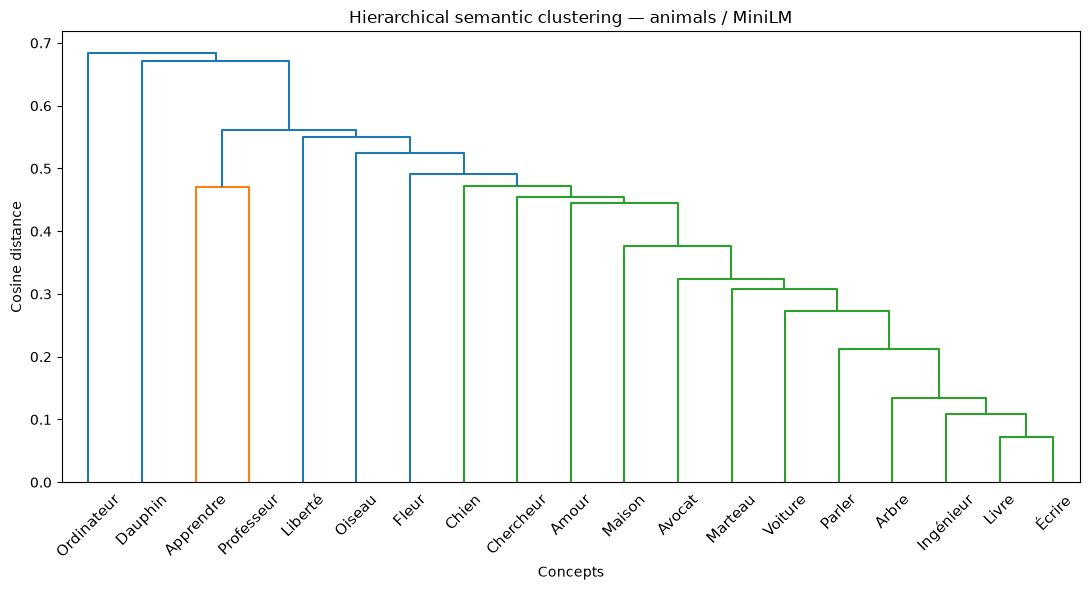

In [116]:
# ============================================================
# EXPERIMENT — Hierarchical semantic clustering
# Step 2: dendrogram from cosine distances
# ============================================================

import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform


# ------------------------------------------------------------
# 1 — Convert similarities to distances
# ------------------------------------------------------------

distance_matrix = 1 - similarity_matrix


# ------------------------------------------------------------
# 2 — Convert square matrix to condensed form
#     required by scipy linkage()
# ------------------------------------------------------------

condensed_distances = squareform(
    distance_matrix.values,
    checks=True,
)


# ------------------------------------------------------------
# 3 — Hierarchical clustering
# ------------------------------------------------------------

Z = linkage(
    condensed_distances,
    method="average",
)


# ------------------------------------------------------------
# 4 — Dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

dendrogram(
    Z,
    labels=concepts,
    leaf_rotation=45,
    leaf_font_size=11,
)

plt.title("Hierarchical semantic clustering — animals / MiniLM")
plt.ylabel("Cosine distance")
plt.xlabel("Concepts")

plt.tight_layout()
plt.show()

In [117]:
from scipy.cluster.hierarchy import linkage

for i, (a, b, distance, size) in enumerate(Z):
    def name(x):
        x = int(x)

        if x < len(concepts):
            return concepts[x]

        return f"Cluster {x}"

    print(
        f"{i+1:2d}. "
        f"{name(a):20s} + {name(b):20s} "
        f"→ distance {distance:.3f}"
    )

 1. Livre                + Écrire               → distance 0.073
 2. Ingénieur            + Cluster 19           → distance 0.109
 3. Arbre                + Cluster 20           → distance 0.134
 4. Parler               + Cluster 21           → distance 0.213
 5. Voiture              + Cluster 22           → distance 0.273
 6. Marteau              + Cluster 23           → distance 0.308
 7. Avocat               + Cluster 24           → distance 0.323
 8. Maison               + Cluster 25           → distance 0.376
 9. Amour                + Cluster 26           → distance 0.445
10. Chercheur            + Cluster 27           → distance 0.455
11. Apprendre            + Professeur           → distance 0.470
12. Chien                + Cluster 28           → distance 0.471
13. Fleur                + Cluster 30           → distance 0.491
14. Oiseau               + Cluster 31           → distance 0.525
15. Liberté              + Cluster 32           → distance 0.550
16. Cluster 29           